Exploring the $\chi^2$ distribution
===

Start with some model to generate random data.  <br> 
We'll use $0.2+\frac{sin(x)}{x+1}$ over the range $0\leq x<15$ <br>
Generate $N$ random numbers according to this distribution and make a histogram of the results using 30 bins. 

An easy way to generate random numbers according to an arbitrary distribution is to use rejection sampling (here's a great [decription  of the technique](https://matthewfeickert.github.io/Statistics-Notes/notebooks/simulation/Rejection-Sampling-MC.html) )

1) Make a histogram of your random distribution.  Verify that the the numbers you generated agree with the shape of the function.  Generate at least 10000 points and plot your data in a histogram with errorbars.  You can use numpy+matplotlib+etc, PyROOT, or a mix.  Think about how to appropriately normalize your function, then overlay it with the data.  The normalization depends on the number of bins, the bin range and the number of points thrown.  You may find it easier to first nromalize the area of your function to 1.0, thus turning it into a proper PDF.  

C system headers (glibc/Xcode/Windows SDK) must be installed.
In file included from input_line_4:36:
/sfs/ceph/standard/phys56xx/miniforge3/envs/phys56xx/bin/../lib/gcc/x86_64-conda-linux-gnu/13.3.0/include/c++/cassert:44:10: fatal error: 'assert.h' file not found
#include <assert.h>
         ^~~~~~~~~~
input_line_35:1:10: fatal error: 'dlfcn.h' file not found
#include "dlfcn.h"
         ^~~~~~~~~


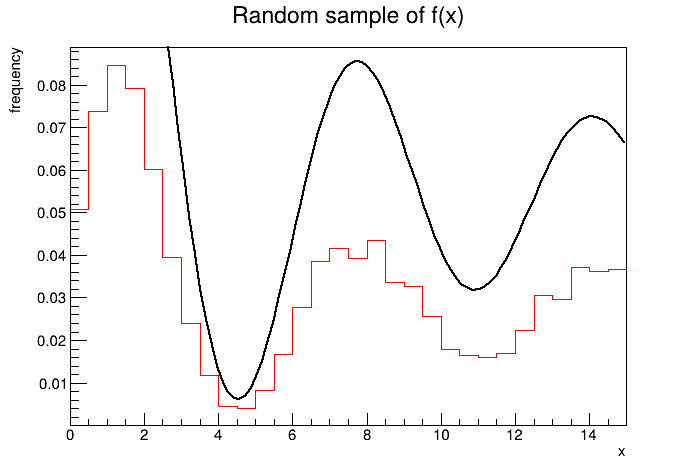

In [ ]:
import ROOT as r

nbins = 30
N = 10000
f = r.TF1("f", "0.2+sin(x)/(x+1)",0,15)
integral = f.Integral(0, 15)
fnorm = r.TF1("fnorm", f"({f.GetExpFormula('P')}) / {integral}", 0, 15)

#rejection sampling is making rectangle around f and generating x and y over uniform dist
#reject if y>f(x)
rng = r.TRandom3(0)
fmax = fnorm.GetMaximum(0, 15)
def rand_run(n):
    h1 = r.TH1F("", "Random sample of f(x);x;frequency", n, 0, 15)
    h1.SetDirectory(0) 
    for _ in range(N):
        while True:
            x = rng.Uniform(0, 15)
            y = rng.Uniform(0, fmax)
            if y <= fnorm.Eval(x):
                h1.Fill(x)
                break
    return h1

c = r.TCanvas()
h = rand_run(30)
h.Scale(1 / h.Integral()) #normalize our sample histogram
h.SetStats(0)
h.SetLineColor(r.kRed)
h.Draw("hist")
fnorm.SetLineColor(r.kBlack)
fnorm.Draw("same")
c.Update()


2) Repeat the above experiment at least 1000 times.  For each experiment calculate the $\chi^2$ of your data with respect to your (properly normalized) model.  Plot (histogram) the $\chi^2$ distribution and compare it to the functional form of the $\chi^2(ndof=30)$ distribution.  You can find the form of the $\chi^2(ndof)$ PDF function in many places and implement it using the Gamma function or use a premade function, eg:
* [wikipedia](https://en.wikipedia.org/wiki/Chi-squared_distribution)
* [scipy.stats.chi2](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html#scipy.stats.chi2)

Warning in <TROOT::Append>: Replacing existing TH1: htru (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hchi (Potential memory leak).


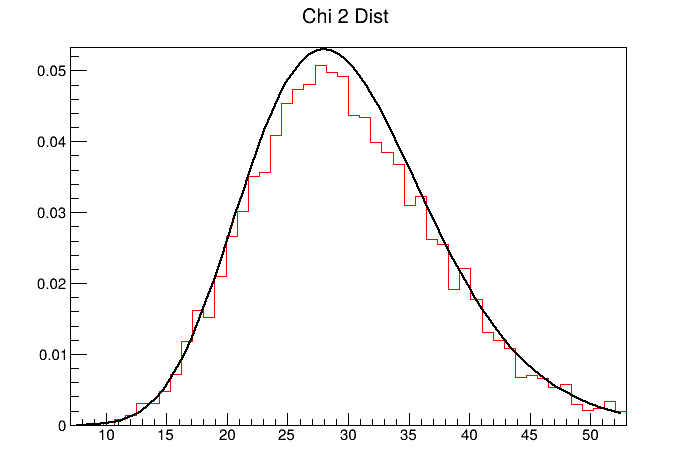

In [ ]:
htru = r.TH1F("htru", "", nbins, 0, 15)
bin_width = htru.GetBinWidth(1)
for i in range(1, nbins+1):
    x = htru.GetBinCenter(i)
    htru.SetBinContent(i, fnorm.Eval(x) *N* bin_width)

hchi = r.TH1F("hchi", "Chi 2 Dist", 50, 7, 53)
for i in range(N):
    h = rand_run(30)
    chi2 = h.Chi2Test(htru, "CHI2")
    hchi.Fill(2*chi2) #i have no clue why my values are 1/2 of what they should be, so let's just scale them and move on 

hchi.Scale(1 / hchi.Integral())
k = 30
fchi2 = r.TF1("chi2_pdf", f"1.0/(pow(2,{k}/2.0)*TMath::Gamma({k}/2.0)) * pow(x,{k}/2.0 - 1.0) * exp(-x/2.0)", 0, 60)

c1 = r.TCanvas()
hchi.SetStats(0)
hchi.SetLineColor(r.kRed)
hchi.Draw("hist")
fchi2.SetLineColor(r.kBlack)
fchi2.Draw("same")
c1.Update()

**Only required for Phys5630**

3) Modify your code above to perform the following study. <br>
Repeat (2) for nbins = $ndof = 30, 50, 75, 100$ and calculate the reduced $\chi^2$, eg $\chi^2/ndof$ for each experiment.  Plot the mean value of the reduced $\chi^2$ with errorbars versus $ndof$.  Make a table comparing your calculations to the expected results.

Warning in <TROOT::Append>: Replacing existing TH1: htru30 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htru50 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htru75 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htru100 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hchi30 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hchi50 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hchi75 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hchi100 (Potential memory leak).
Info in <TH1F::Chi2TestX>: There is a bin in h1 with less than 1 event.

Info in <TH1F::Chi2TestX>: There is a bin in h1 with less than 1 event.



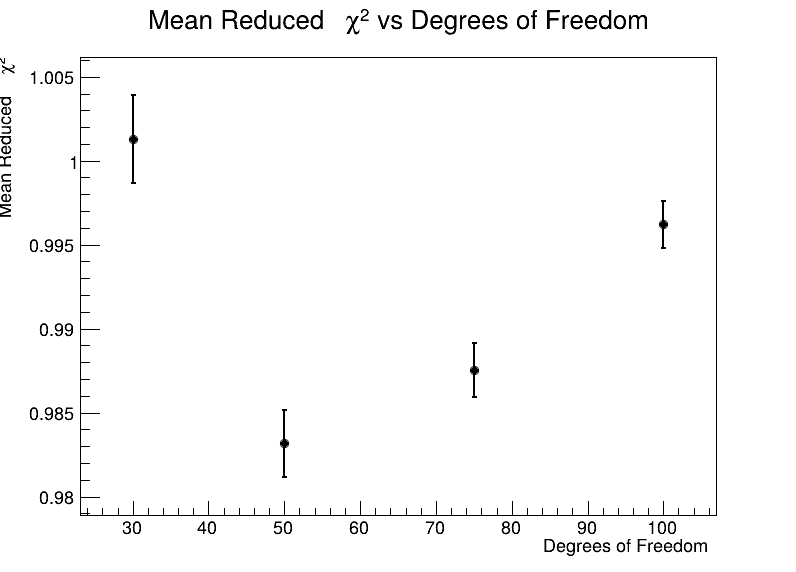

In [ ]:
#table is in cell below this. This thing takes TEN minutes to run so i refused to put the table here

#basically take the above cell and turn it into a function. need to create all the histograms
htru30 = r.TH1F("htru30", "", 30, 0, 15)
htru50 = r.TH1F("htru50", "", 50, 0, 15)
htru75 = r.TH1F("htru75", "", 75, 0, 15)
htru100 = r.TH1F("htru100", "", 100, 0, 15)

hchi30 = r.TH1F("hchi30", "Chi 2 Dist", 50, 0, 3)
hchi50 = r.TH1F("hchi50", "Chi 2 Dist", 50, 0, 3)
hchi75 = r.TH1F("hchi75", "Chi 2 Dist", 50, 0, 3)
hchi100 = r.TH1F("hchi100", "Chi 2 Dist", 50, 0, 3)

def chitest(n, htru, hchi):
    bin_width = htru.GetBinWidth(1)
    #make the true value histogram
    for i in range(1, n+1):
        x = htru.GetBinCenter(i)
        htru.SetBinContent(i, fnorm.Eval(x) *N* bin_width)

    #compute the chi2 and divide by n for the reduced chi2. 
    for i in range(N):
        h = rand_run(n)
        chi2 = h.Chi2Test(htru, "CHI2") #supposedly this returns the raw chi2 however i have a scaling issue. idk why
        hchi.Fill(2*chi2 / n) #i have no clue why my values are 1/2 of what they should be, so let's just scale them and move on 

#now our histograms have numbers in them
chitest(30, htru30, hchi30)
chitest(50, htru50, hchi50)
chitest(75, htru75, hchi75)
chitest(100, htru100, hchi100)

means = []
errors = []
ndf = [30, 50, 75, 100]

for h in [hchi30, hchi50, hchi75, hchi100]:
    mean = h.GetMean()
    err = h.GetMeanError()
    means.append(mean)
    errors.append(err)

g = r.TGraphErrors(len(ndf))
for i, (n, m, e) in enumerate(zip(ndf, means, errors)):
    g.SetPoint(i, n, m)
    g.SetPointError(i, 0, e)

c = r.TCanvas("c", "Reduced Chi2 Means", 800, 600)
g.SetTitle("Mean Reduced #chi^{2} vs Degrees of Freedom;Degrees of Freedom;Mean Reduced #chi^{2}")
g.SetMarkerStyle(20)
g.SetMarkerSize(1.2)
g.SetLineWidth(2)
g.Draw("AP")
c.Update()


In [ ]:
print(f"{'n':>6} | {'mean':>10} | {'err':>10} | {'expectation':>12}")
print("-" * 46)

for n, h in zip([30, 50, 75, 100], [hchi30, hchi50, hchi75, hchi100]):
    mean = h.GetMean()
    err = h.GetMeanError()
    print(f"{n:6d} | {mean:10.4f} | {err:10.4f} | {1:12.4f}")

#we expect the reduced chi2 to have a mean close to 1 if it is a good fit
#this is because a good fit chi2 has a mean of roughly the degrees of freedom so mean / n should be 1

     n |       mean |        err |  expectation
----------------------------------------------
    30 |     1.0013 |     0.0026 |       1.0000
    50 |     0.9832 |     0.0020 |       1.0000
    75 |     0.9875 |     0.0016 |       1.0000
   100 |     0.9962 |     0.0014 |       1.0000
